UNIT ECONOMICS INPUTS
Experiment customers: 4661
Groups: ['Control', 'Treatment']

BUSINESS ASSUMPTIONS
Value per shifted session: ₹20.00
Intervention cost per treated customer: ₹5.00
Fixed implementation cost: ₹0.00

UNIT ECONOMICS SUMMARY
                              metric         value
                  Control shift rate      0.115196
                Treatment shift rate      0.161874
              Incremental shift rate      0.046678
            Control shifted sessions  12081.000000
          Treatment shifted sessions  17316.000000
        Incremental shifted sessions   5235.000000
           Value per shifted session     20.000000
                   Incremental value 104700.000000
                   Intervention cost  11785.000000
           Fixed implementation cost      0.000000
             Total intervention cost  11785.000000
               Net incremental value  92915.000000
                                 ROI      7.884175
Cost per incremental shifted session      2.2

,customer_segment,experiment_group,customers,responders,peak_sessions,shifted_peak_sessions_treatment,response_rate,session_shift_rate_treatment,shifted_peak_sessions_control,session_shift_rate_control,incremental_shifted_sessions,incremental_value,intervention_cost,net_incremental_value,roi
1,High_Mileage,Treatment,233,81,28728,6923,0.347639,0.240984,5260,0.187095,1663,33260.0,1165.0,32095.0,27.549356
3,Routine_Commuter,Treatment,1055,307,46559,6254,0.290995,0.134324,3905,0.088659,2349,46980.0,5275.0,41705.0,7.906161
2,Price_Sensitive,Treatment,468,145,15298,2615,0.309829,0.170937,1869,0.112293,746,14920.0,2340.0,12580.0,5.376068
0,Convenience_First,Treatment,601,145,16387,1524,0.241265,0.093001,1047,0.065152,477,9540.0,3005.0,6535.0,2.174709



Saved: ../outputs/tables/unit_economics_by_segment.csv


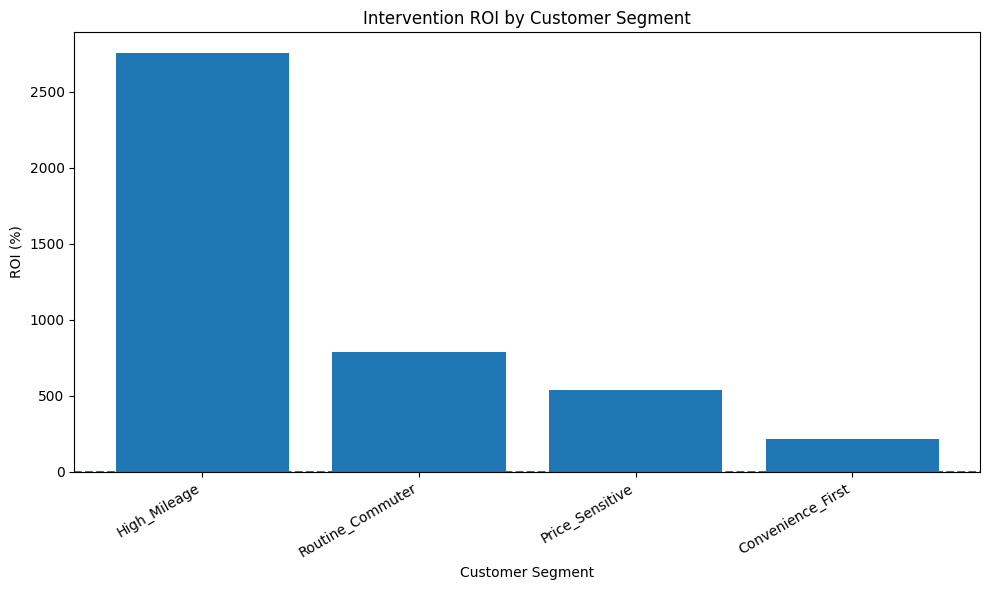


Segment economics section complete.


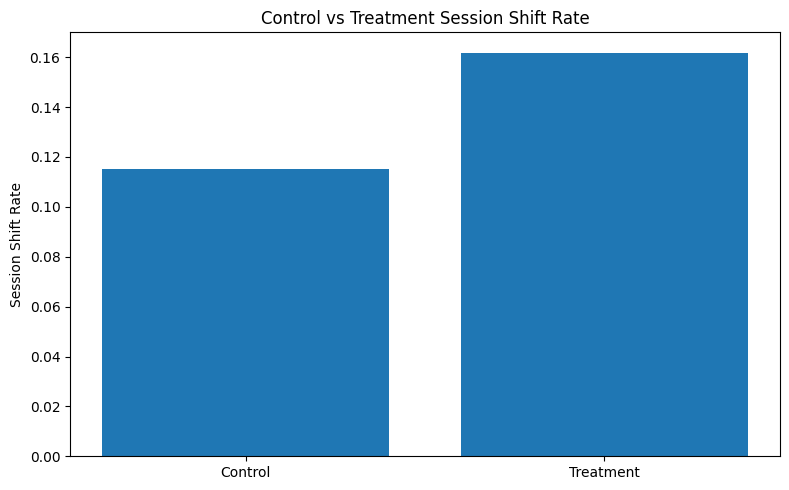

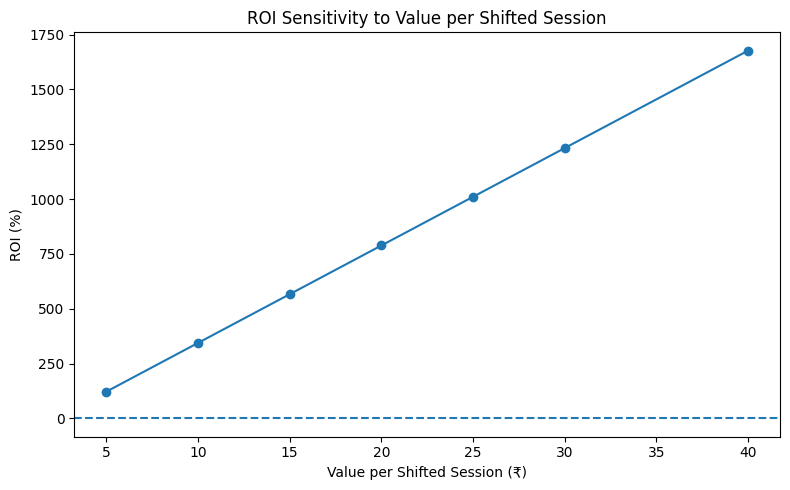

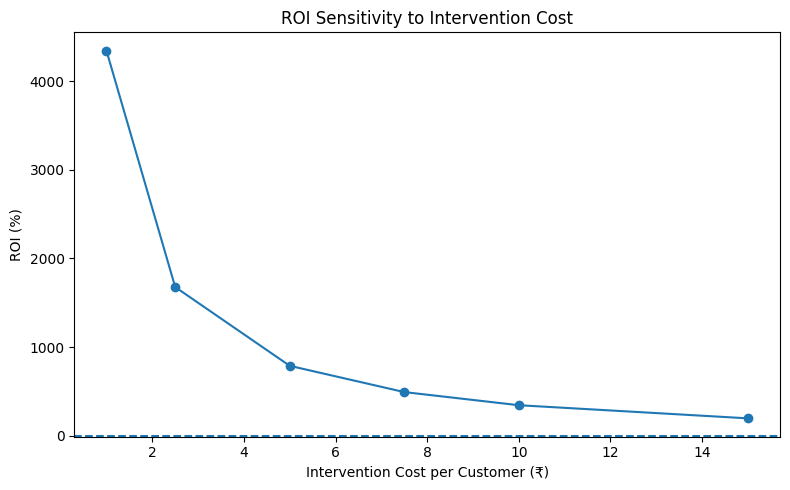

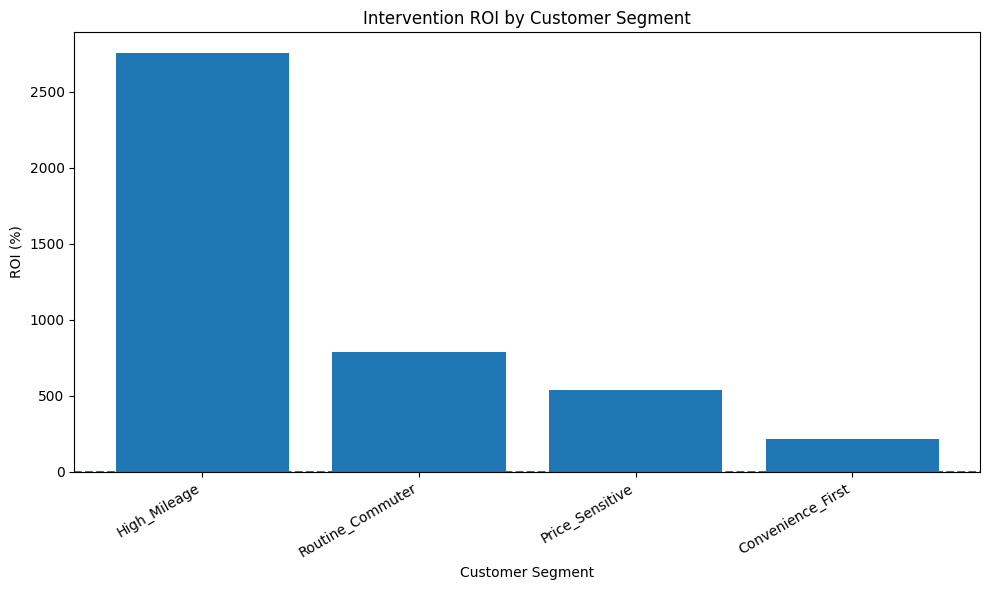



STAGE 7 — UNIT ECONOMICS COMPLETE
Treatment customers: 2,357
Incremental shifted sessions: 5,235
Incremental shift rate: 4.67%
Incremental value: ₹104,700.00
Intervention cost: ₹11,785.00
Net incremental value: ₹92,915.00
ROI: 788.42%
Break-even value/session: ₹2.25
Scale-up eligible customers: 4,661
Scale-up estimated incremental sessions: 10,352
Scale-up estimated net value: ₹183,740.69
Scale-up ROI: 788.42%

Outputs saved to:
../outputs/tables
../outputs/figures

Stage 7 complete.


In [3]:
# ============================================================
# TATA POWER EV CHARGING ANALYTICS
# STAGE 7 — UNIT ECONOMICS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. LOAD EXPERIMENT RESULTS
# ------------------------------------------------------------

OUTPUT_TABLE_PATH = Path("../outputs/tables")
OUTPUT_FIGURE_PATH = Path("../outputs/figures")

OUTPUT_TABLE_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_PATH.mkdir(parents=True, exist_ok=True)

group_results = pd.read_csv(
    OUTPUT_TABLE_PATH / "experiment_group_results.csv"
)

segment_results = pd.read_csv(
    OUTPUT_TABLE_PATH / "experiment_segment_results.csv"
)

experiment = pd.read_csv(
    OUTPUT_TABLE_PATH / "experiment_customer_outcomes.csv"
)

print("UNIT ECONOMICS INPUTS")
print("=" * 60)
print("Experiment customers:", len(experiment))
print("Groups:", group_results["experiment_group"].tolist())


# ------------------------------------------------------------
# 2. DEFINE BUSINESS ASSUMPTIONS
# ------------------------------------------------------------
#
# These are explicit modelling assumptions rather than hidden
# assumptions. They can be changed later for sensitivity analysis.
#
# Revenue / economics model:
#
#   shifted session = one peak session successfully shifted
#   incremental value = value generated from that shifted session
#
# Intervention costs are modelled on a per eligible customer basis.
# ------------------------------------------------------------

VALUE_PER_SHIFTED_SESSION = 20.0
INTERVENTION_COST_PER_CUSTOMER = 5.0

# Optional implementation/platform fixed cost
FIXED_IMPLEMENTATION_COST = 0.0

print("\nBUSINESS ASSUMPTIONS")
print("=" * 60)
print(f"Value per shifted session: ₹{VALUE_PER_SHIFTED_SESSION:,.2f}")
print(
    f"Intervention cost per treated customer: "
    f"₹{INTERVENTION_COST_PER_CUSTOMER:,.2f}"
)
print(f"Fixed implementation cost: ₹{FIXED_IMPLEMENTATION_COST:,.2f}")


# ------------------------------------------------------------
# 3. EXTRACT CONTROL / TREATMENT METRICS
# ------------------------------------------------------------

control = group_results.loc[
    group_results["experiment_group"] == "Control"
].iloc[0]

treatment = group_results.loc[
    group_results["experiment_group"] == "Treatment"
].iloc[0]

control_customers = int(control["customers"])
treatment_customers = int(treatment["customers"])

control_shifted_sessions = float(control["shifted_peak_sessions"])
treatment_shifted_sessions = float(treatment["shifted_peak_sessions"])

control_shift_rate = float(control["session_shift_rate"])
treatment_shift_rate = float(treatment["session_shift_rate"])


# ------------------------------------------------------------
# 4. INCREMENTAL IMPACT
# ------------------------------------------------------------

incremental_shift_rate = (
    treatment_shift_rate - control_shift_rate
)

incremental_shifted_sessions = (
    treatment_shifted_sessions
    - control_shifted_sessions
)

# Treatment group's observed incremental sessions
incremental_value = (
    incremental_shifted_sessions
    * VALUE_PER_SHIFTED_SESSION
)

intervention_cost = (
    treatment_customers
    * INTERVENTION_COST_PER_CUSTOMER
)

net_incremental_value = (
    incremental_value
    - intervention_cost
)

if intervention_cost > 0:
    roi = net_incremental_value / intervention_cost
else:
    roi = np.nan

cost_per_incremental_shift = (
    intervention_cost / incremental_shifted_sessions
    if incremental_shifted_sessions > 0
    else np.nan
)

value_per_incremental_shift = VALUE_PER_SHIFTED_SESSION


# ------------------------------------------------------------
# 5. UNIT ECONOMICS SUMMARY
# ------------------------------------------------------------

unit_economics = pd.DataFrame({
    "metric": [
        "Control shift rate",
        "Treatment shift rate",
        "Incremental shift rate",
        "Control shifted sessions",
        "Treatment shifted sessions",
        "Incremental shifted sessions",
        "Value per shifted session",
        "Incremental value",
        "Intervention cost",
        "Fixed implementation cost",
        "Total intervention cost",
        "Net incremental value",
        "ROI",
        "Cost per incremental shifted session"
    ],
    "value": [
        control_shift_rate,
        treatment_shift_rate,
        incremental_shift_rate,
        control_shifted_sessions,
        treatment_shifted_sessions,
        incremental_shifted_sessions,
        VALUE_PER_SHIFTED_SESSION,
        incremental_value,
        intervention_cost,
        FIXED_IMPLEMENTATION_COST,
        intervention_cost + FIXED_IMPLEMENTATION_COST,
        incremental_value - intervention_cost - FIXED_IMPLEMENTATION_COST,
        (
            (
                incremental_value
                - intervention_cost
                - FIXED_IMPLEMENTATION_COST
            )
            / (intervention_cost + FIXED_IMPLEMENTATION_COST)
            if (intervention_cost + FIXED_IMPLEMENTATION_COST) > 0
            else np.nan
        ),
        cost_per_incremental_shift
    ]
})

print("\nUNIT ECONOMICS SUMMARY")
print("=" * 60)
print(unit_economics.to_string(index=False))


# ------------------------------------------------------------
# 6. PER-CUSTOMER ECONOMICS
# ------------------------------------------------------------

treatment_incremental_sessions_per_customer = (
    incremental_shifted_sessions / treatment_customers
)

incremental_value_per_treated_customer = (
    treatment_incremental_sessions_per_customer
    * VALUE_PER_SHIFTED_SESSION
)

net_value_per_treated_customer = (
    incremental_value_per_treated_customer
    - INTERVENTION_COST_PER_CUSTOMER
)

customer_economics = pd.DataFrame({
    "metric": [
        "Treatment customers",
        "Incremental shifted sessions",
        "Incremental shifted sessions / treated customer",
        "Incremental value / treated customer",
        "Intervention cost / treated customer",
        "Net value / treated customer"
    ],
    "value": [
        treatment_customers,
        incremental_shifted_sessions,
        treatment_incremental_sessions_per_customer,
        incremental_value_per_treated_customer,
        INTERVENTION_COST_PER_CUSTOMER,
        net_value_per_treated_customer
    ]
})

print("\nPER-CUSTOMER ECONOMICS")
print("=" * 60)
print(customer_economics.to_string(index=False))


# ------------------------------------------------------------
# 7. SCALE-UP ECONOMICS
# ------------------------------------------------------------
#
# Estimate economics if the intervention is rolled out to all
# intervention-eligible customers.
# ------------------------------------------------------------

eligible_customers = int(
    experiment["eligible_for_intervention"].sum()
)

# Use treatment incremental performance as the estimated effect
# for the eligible population.

scaled_incremental_sessions = (
    treatment_incremental_sessions_per_customer
    * eligible_customers
)

scaled_incremental_value = (
    scaled_incremental_sessions
    * VALUE_PER_SHIFTED_SESSION
)

scaled_intervention_cost = (
    eligible_customers
    * INTERVENTION_COST_PER_CUSTOMER
)

scaled_net_value = (
    scaled_incremental_value
    - scaled_intervention_cost
    - FIXED_IMPLEMENTATION_COST
)

scaled_roi = (
    scaled_net_value
    / (scaled_intervention_cost + FIXED_IMPLEMENTATION_COST)
    if (scaled_intervention_cost + FIXED_IMPLEMENTATION_COST) > 0
    else np.nan
)

scale_up = pd.DataFrame({
    "metric": [
        "Eligible customers",
        "Estimated incremental shifted sessions",
        "Estimated incremental value",
        "Intervention cost",
        "Fixed implementation cost",
        "Net incremental value",
        "ROI"
    ],
    "value": [
        eligible_customers,
        scaled_incremental_sessions,
        scaled_incremental_value,
        scaled_intervention_cost,
        FIXED_IMPLEMENTATION_COST,
        scaled_net_value,
        scaled_roi
    ]
})

print("\nSCALE-UP ECONOMICS")
print("=" * 60)
print(scale_up.to_string(index=False))


# ------------------------------------------------------------
# 8. BREAK-EVEN ANALYSIS
# ------------------------------------------------------------

break_even_sessions = (
    (
        INTERVENTION_COST_PER_CUSTOMER
        * treatment_customers
    )
    + FIXED_IMPLEMENTATION_COST
) / VALUE_PER_SHIFTED_SESSION

break_even_value_per_session = (
    (
        INTERVENTION_COST_PER_CUSTOMER
        * treatment_customers
    )
    + FIXED_IMPLEMENTATION_COST
) / incremental_shifted_sessions

break_even = pd.DataFrame({
    "metric": [
        "Break-even incremental shifted sessions",
        "Break-even value per incremental shifted session"
    ],
    "value": [
        break_even_sessions,
        break_even_value_per_session
    ]
})

print("\nBREAK-EVEN ANALYSIS")
print("=" * 60)
print(break_even.to_string(index=False))


# ------------------------------------------------------------
# 9. SENSITIVITY ANALYSIS — VALUE PER SHIFTED SESSION
# ------------------------------------------------------------

value_scenarios = [
    5,
    10,
    15,
    20,
    25,
    30,
    40
]

sensitivity_rows = []

for value_per_session in value_scenarios:

    scenario_value = (
        incremental_shifted_sessions
        * value_per_session
    )

    scenario_net = (
        scenario_value
        - intervention_cost
        - FIXED_IMPLEMENTATION_COST
    )

    total_cost = (
        intervention_cost
        + FIXED_IMPLEMENTATION_COST
    )

    scenario_roi = (
        scenario_net / total_cost
        if total_cost > 0
        else np.nan
    )

    sensitivity_rows.append({
        "value_per_shifted_session": value_per_session,
        "incremental_value": scenario_value,
        "total_cost": total_cost,
        "net_incremental_value": scenario_net,
        "roi": scenario_roi
    })

sensitivity = pd.DataFrame(sensitivity_rows)

print("\nSENSITIVITY — VALUE PER SHIFTED SESSION")
print("=" * 60)
print(sensitivity.to_string(index=False))


# ------------------------------------------------------------
# 10. SENSITIVITY ANALYSIS — INTERVENTION COST
# ------------------------------------------------------------

cost_scenarios = [
    1,
    2.5,
    5,
    7.5,
    10,
    15
]

cost_sensitivity_rows = []

for cost_per_customer in cost_scenarios:

    scenario_cost = (
        treatment_customers
        * cost_per_customer
        + FIXED_IMPLEMENTATION_COST
    )

    scenario_net = (
        incremental_value
        - scenario_cost
    )

    scenario_roi = (
        scenario_net / scenario_cost
        if scenario_cost > 0
        else np.nan
    )

    cost_sensitivity_rows.append({
        "intervention_cost_per_customer": cost_per_customer,
        "incremental_value": incremental_value,
        "total_cost": scenario_cost,
        "net_incremental_value": scenario_net,
        "roi": scenario_roi
    })

cost_sensitivity = pd.DataFrame(cost_sensitivity_rows)

print("\nSENSITIVITY — INTERVENTION COST")
print("=" * 60)
print(cost_sensitivity.to_string(index=False))


# ------------------------------------------------------------
# 11. SEGMENT-LEVEL UNIT ECONOMICS
# ------------------------------------------------------------

print("\nSEGMENT RESULTS COLUMNS")
print("=" * 60)
print(segment_results.columns.tolist())

# Detect the segment column used in your actual output
segment_col_candidates = [
    "customer_segment",
    "customer_segment_x",
    "customer_segment_y",
    "segment"
]

segment_col = next(
    (c for c in segment_col_candidates if c in segment_results.columns),
    None
)

if segment_col is None:
    print("\nWARNING: Could not identify segment column.")
    print("Available columns:", segment_results.columns.tolist())

    segment_economics = pd.DataFrame()

else:
    print(f"\nUsing segment column: {segment_col}")

    # Work on a clean copy
    segment_economics_raw = segment_results.copy()

    # Standardise segment column name
    segment_economics_raw = segment_economics_raw.rename(
        columns={segment_col: "customer_segment"}
    )

    # Identify treatment/control rows
    treatment_segments = segment_economics_raw[
        segment_economics_raw["experiment_group"] == "Treatment"
    ].copy()

    control_segments = segment_economics_raw[
        segment_economics_raw["experiment_group"] == "Control"
    ].copy()

    # Columns needed from control
    control_cols = [
        "customer_segment",
        "shifted_peak_sessions",
        "session_shift_rate"
    ]

    # Keep only columns that actually exist
    control_cols = [
        c for c in control_cols
        if c in control_segments.columns
    ]

    segment_economics = treatment_segments.merge(
        control_segments[control_cols],
        on="customer_segment",
        how="left",
        suffixes=("_treatment", "_control")
    )

    # --------------------------------------------------------
    # Calculate incremental impact
    # --------------------------------------------------------

    segment_economics["incremental_shifted_sessions"] = (
        segment_economics["shifted_peak_sessions_treatment"]
        - segment_economics["shifted_peak_sessions_control"]
    )

    segment_economics["incremental_value"] = (
        segment_economics["incremental_shifted_sessions"]
        * VALUE_PER_SHIFTED_SESSION
    )

    segment_economics["intervention_cost"] = (
        segment_economics["customers"]
        * INTERVENTION_COST_PER_CUSTOMER
    )

    segment_economics["net_incremental_value"] = (
        segment_economics["incremental_value"]
        - segment_economics["intervention_cost"]
    )

    segment_economics["roi"] = np.where(
        segment_economics["intervention_cost"] > 0,
        segment_economics["net_incremental_value"]
        / segment_economics["intervention_cost"],
        np.nan
    )

    segment_economics = segment_economics.sort_values(
        "roi",
        ascending=False
    )

    print("\nSEGMENT ECONOMICS")
    print("=" * 60)

    display(segment_economics)


# ------------------------------------------------------------
# 12. SAVE SEGMENT ECONOMICS
# ------------------------------------------------------------

if not segment_economics.empty:

    segment_economics.to_csv(
        OUTPUT_TABLE_PATH / "unit_economics_by_segment.csv",
        index=False
    )

    print(
        "\nSaved:",
        OUTPUT_TABLE_PATH / "unit_economics_by_segment.csv"
    )


# ------------------------------------------------------------
# 13. FIGURE — SEGMENT ROI
# ------------------------------------------------------------

if (
    not segment_economics.empty
    and "roi" in segment_economics.columns
):

    plot_segment = segment_economics.dropna(
        subset=["roi"]
    ).copy()

    plt.figure(figsize=(10, 6))

    plt.bar(
        plot_segment["customer_segment"],
        plot_segment["roi"] * 100
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("ROI (%)")
    plt.title("Intervention ROI by Customer Segment")

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_FIGURE_PATH / "roi_by_segment.png",
        dpi=150
    )

    plt.show()

print("\nSegment economics section complete.")

# ------------------------------------------------------------
# 12. SAVE OUTPUT TABLES
# ------------------------------------------------------------

unit_economics.to_csv(
    OUTPUT_TABLE_PATH / "unit_economics_summary.csv",
    index=False
)

customer_economics.to_csv(
    OUTPUT_TABLE_PATH / "unit_economics_per_customer.csv",
    index=False
)

scale_up.to_csv(
    OUTPUT_TABLE_PATH / "unit_economics_scale_up.csv",
    index=False
)

break_even.to_csv(
    OUTPUT_TABLE_PATH / "unit_economics_break_even.csv",
    index=False
)

sensitivity.to_csv(
    OUTPUT_TABLE_PATH / "unit_economics_sensitivity_value.csv",
    index=False
)

cost_sensitivity.to_csv(
    OUTPUT_TABLE_PATH / "unit_economics_sensitivity_cost.csv",
    index=False
)

if isinstance(segment_economics, pd.DataFrame):
    segment_economics.to_csv(
        OUTPUT_TABLE_PATH / "unit_economics_by_segment.csv",
        index=False
    )


# ------------------------------------------------------------
# 13. FIGURE 1 — CONTROL VS TREATMENT SHIFT RATE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ["Control", "Treatment"],
    [control_shift_rate, treatment_shift_rate]
)

plt.ylabel("Session Shift Rate")
plt.title("Control vs Treatment Session Shift Rate")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH / "control_vs_treatment_shift_rate.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# 14. FIGURE 2 — ROI SENSITIVITY TO SESSION VALUE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    sensitivity["value_per_shifted_session"],
    sensitivity["roi"] * 100,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Value per Shifted Session (₹)")
plt.ylabel("ROI (%)")
plt.title("ROI Sensitivity to Value per Shifted Session")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH / "roi_sensitivity_value.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# 15. FIGURE 3 — ROI SENSITIVITY TO INTERVENTION COST
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    cost_sensitivity["intervention_cost_per_customer"],
    cost_sensitivity["roi"] * 100,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Intervention Cost per Customer (₹)")
plt.ylabel("ROI (%)")
plt.title("ROI Sensitivity to Intervention Cost")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH / "roi_sensitivity_cost.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# 16. FIGURE 4 — SEGMENT ECONOMIC ATTRACTIVENESS
# ------------------------------------------------------------

if (
    isinstance(segment_economics, pd.DataFrame)
    and "roi" in segment_economics.columns
):

    plot_segment = segment_economics.dropna(
        subset=["roi"]
    ).copy()

    plt.figure(figsize=(10, 6))

    plt.bar(
        plot_segment["customer_segment"],
        plot_segment["roi"] * 100
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("ROI (%)")
    plt.title("Intervention ROI by Customer Segment")
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()

    plt.savefig(
        OUTPUT_FIGURE_PATH / "roi_by_segment.png",
        dpi=150
    )

    plt.show()


# ------------------------------------------------------------
# 17. FINAL BUSINESS SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("STAGE 7 — UNIT ECONOMICS COMPLETE")
print("=" * 70)

print(f"Treatment customers: {treatment_customers:,}")
print(f"Incremental shifted sessions: {incremental_shifted_sessions:,.0f}")
print(
    f"Incremental shift rate: "
    f"{incremental_shift_rate:.2%}"
)
print(
    f"Incremental value: "
    f"₹{incremental_value:,.2f}"
)
print(
    f"Intervention cost: "
    f"₹{intervention_cost:,.2f}"
)
print(
    f"Net incremental value: "
    f"₹{net_incremental_value:,.2f}"
)

if not np.isnan(roi):
    print(f"ROI: {roi:.2%}")

print(
    f"Break-even value/session: "
    f"₹{break_even_value_per_session:,.2f}"
)

print(
    f"Scale-up eligible customers: "
    f"{eligible_customers:,}"
)

print(
    f"Scale-up estimated incremental sessions: "
    f"{scaled_incremental_sessions:,.0f}"
)

print(
    f"Scale-up estimated net value: "
    f"₹{scaled_net_value:,.2f}"
)

if not np.isnan(scaled_roi):
    print(f"Scale-up ROI: {scaled_roi:.2%}")

print("\nOutputs saved to:")
print(OUTPUT_TABLE_PATH)
print(OUTPUT_FIGURE_PATH)

print("\nStage 7 complete.")